In [1]:
import pandas as pd
import openpyxl
from openpyxl.styles import Font, Alignment, PatternFill
import matplotlib.pyplot as plt
import math
from openpyxl.drawing.image import Image
import numpy as np # Добавлен импорт numpy

   № П/П Дата исследований  Возраст бройлеров, дней  E. acervulina  \
0      1         6.10.2025                        5              2   
1      2        10.10.2025                       10              1   
2      3        15.10.2025                       15              3   
3      4        20.10.2025                       20              3   
4      5        25.10.2025                       25              2   
5      6        30.10.2025                       30              2   
6      7         5.11.2025                       35              1   
7      8        10.11.2025                       40              0   

   E. tenella  E. nicatrix  
0           0            0  
1           0            0  
2           1            0  
3           1            1  
4           1            0  
5           1            0  
6           2            0  
7           3            0  


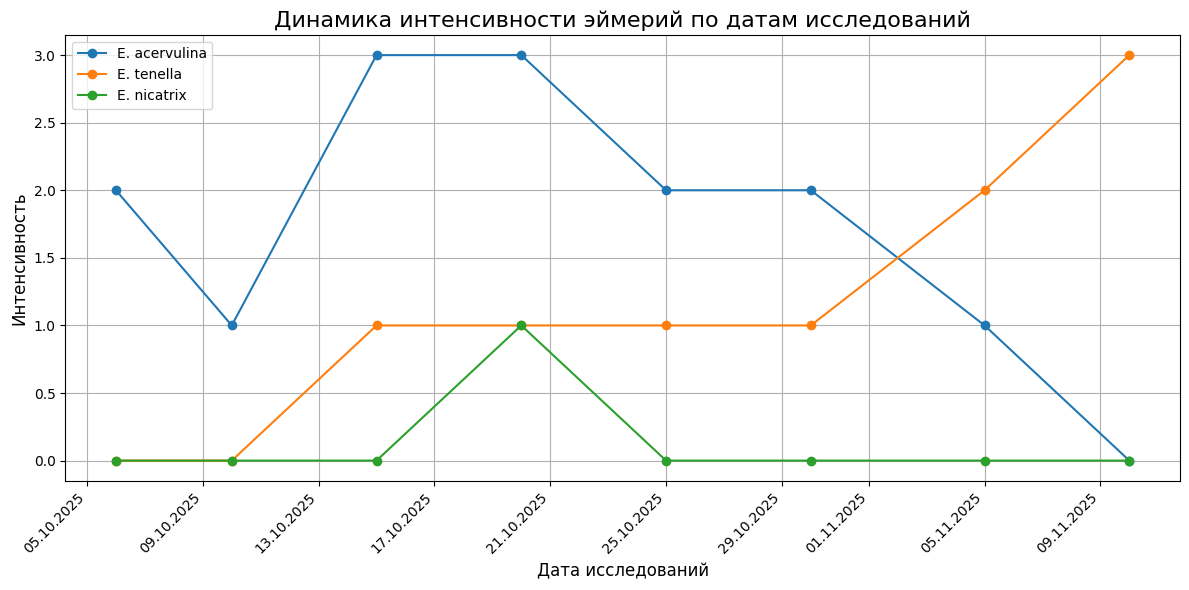

In [11]:

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
data = {
    '№ П/П': [1, 2, 3, 4, 5, 6, 7, 8],
    'Дата исследований': ['6.10.2025', '10.10.2025', '15.10.2025', '20.10.2025', '25.10.2025', '30.10.2025', '5.11.2025', '10.11.2025'],
    'Возраст бройлеров, дней': [5, 10, 15, 20, 25, 30, 35, 40],
    'E. acervulina': [2, 1, 3, 3, 2, 2, 1, 0],
    'E. tenella': [0, 0, 1, 1, 1, 1, 2, 3],
    'E. nicatrix': [0, 0, 0, 1, 0, 0, 0, 0]
}

df = pd.DataFrame(data)

print(df)

# Преобразуем столбец 'Дата исследований' в формат datetime
df['Дата исследований'] = pd.to_datetime(df['Дата исследований'], format='%d.%m.%Y')

# Создаем график
plt.figure(figsize=(12, 6))  # Увеличиваем размер графика для лучшей читаемости

# Строим графики для каждого вида эймерий
plt.plot(df['Дата исследований'], df['E. acervulina'], marker='o', label='E. acervulina')
plt.plot(df['Дата исследований'], df['E. tenella'], marker='o', label='E. tenella')
plt.plot(df['Дата исследований'], df['E. nicatrix'], marker='o', label='E. nicatrix')

# Настраиваем график
plt.title('Динамика интенсивности эймерий по датам исследований', fontsize=16)
plt.xlabel('Дата исследований', fontsize=12)
plt.ylabel('Интенсивность', fontsize=12)
plt.xticks(rotation=45, ha='right')  # Поворачиваем подписи оси x для лучшей читаемости

# Настраиваем формат даты на оси x
date_format = mdates.DateFormatter('%d.%m.%Y')
plt.gca().xaxis.set_major_formatter(date_format)
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator()) #Автоматическая расстановка дат

plt.grid(True)  # Добавляем сетку для лучшей читаемости
plt.legend()  # Добавляем легенду
plt.tight_layout()  # Автоматически корректируем параметры расположения элементов графика
plt.show()

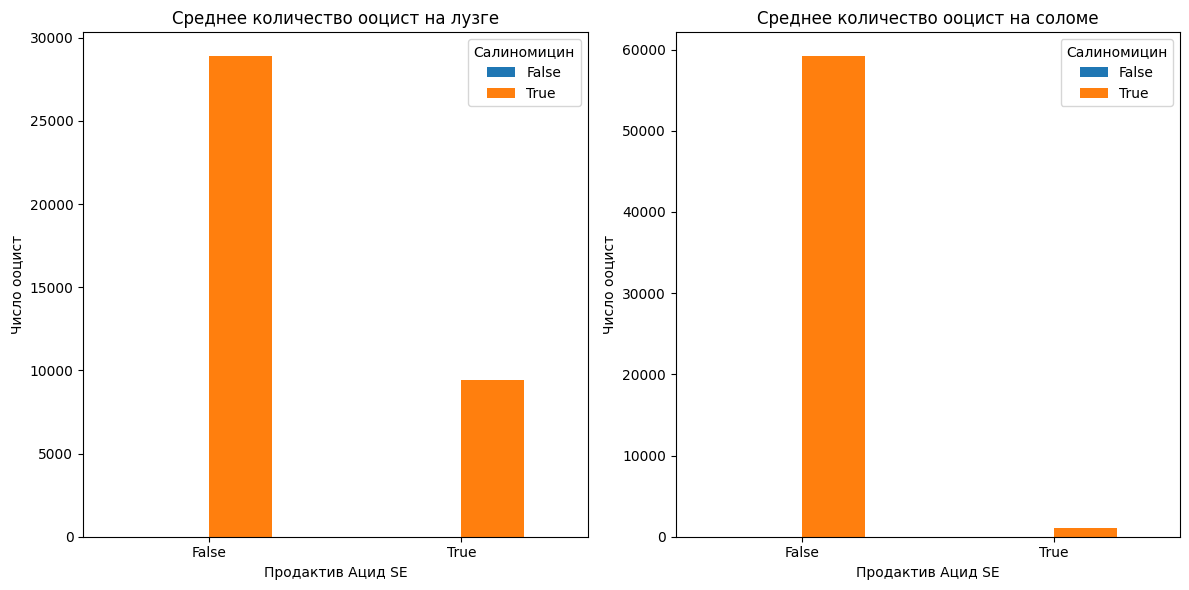

In [18]:
import pandas as pd

data = {
    '№ П/П': [1, 2, 3, 4, 5, 6, 7, 8],
    'Возраст бройлеров, дней': [5, 10, 15, 20, 25, 30, 35, 40],
    'Продактив Ацид SE': [False, False, True, False, False, True, False, False],
    'Салиномицин': [True, True, True, True, True, True, False, False],
    'Количество ооцист в 1грамме помета бройлеров, штук, при содержании на подстилке Лузга': [79992, 3333, 18887, 29970, 2222, 0, 0, 0],
    'Количество ооцист в 1грамме помета бройлеров, штук, при содержании на подстилке Солома': [93334, 4444, 2222, 16665, 122210, 0, 0, 0]
}


df = pd.DataFrame(data)

# Grouping the data for plotting.
df_grouped_luzga = df.groupby(['Продактив Ацид SE', 'Салиномицин'])['Количество ооцист в 1грамме помета бройлеров, штук, при содержании на подстилке Лузга'].mean().unstack()
df_grouped_soloma = df.groupby(['Продактив Ацид SE', 'Салиномицин'])['Количество ооцист в 1грамме помета бройлеров, штук, при содержании на подстилке Солома'].mean().unstack()

# Plotting the grouped data for better comparison
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

df_grouped_luzga.plot(kind='bar', ax=axes[0], rot=0)
axes[0].set_title('Среднее количество ооцист на лузге')
axes[0].set_xlabel('Продактив Ацид SE')
axes[0].set_ylabel('Число ооцист')
axes[0].legend(title='Салиномицин')

df_grouped_soloma.plot(kind='bar', ax=axes[1], rot=0)
axes[1].set_title('Среднее количество ооцист на соломе')
axes[1].set_xlabel('Продактив Ацид SE')
axes[1].set_ylabel('Число ооцист')
axes[1].legend(title='Салиномицин')

plt.tight_layout()
plt.show()

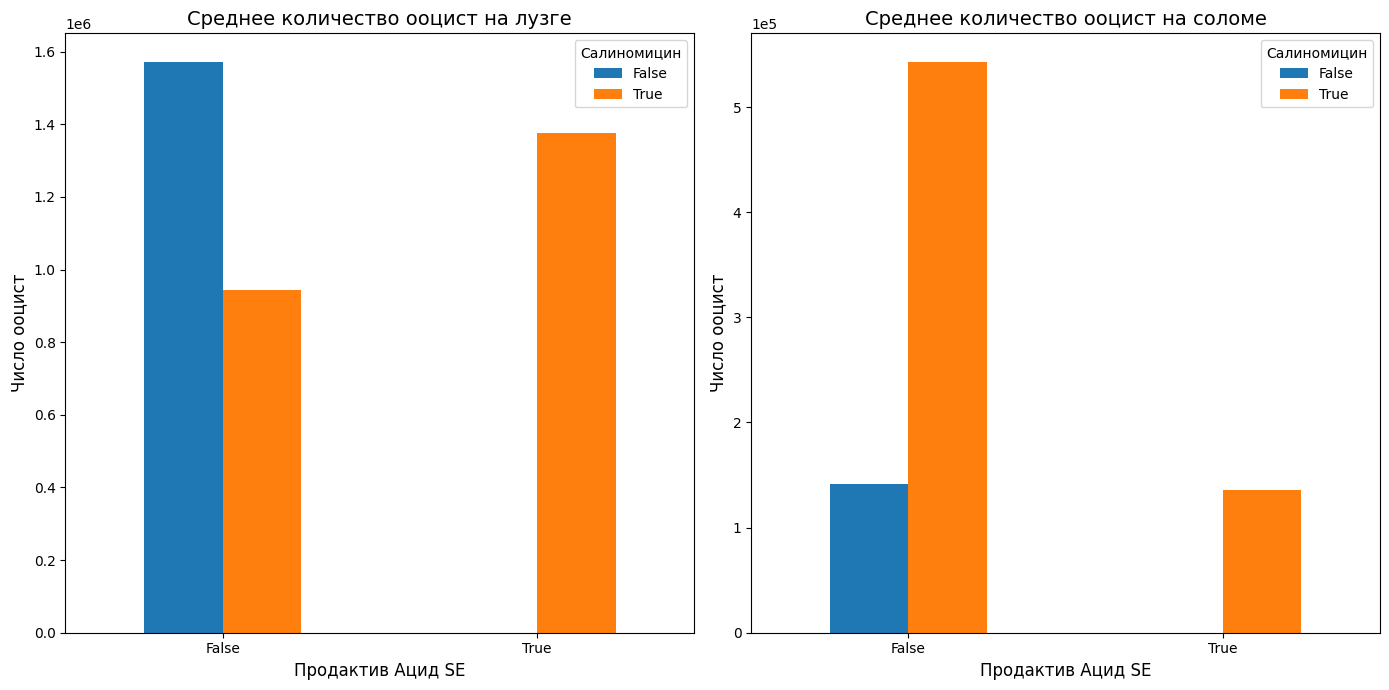

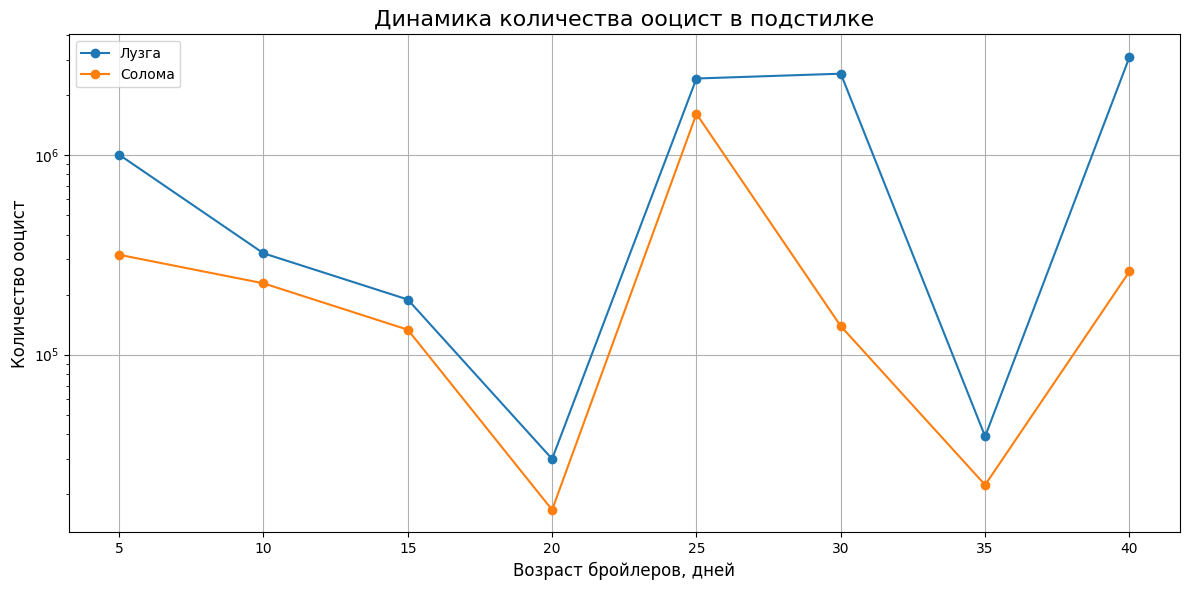

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    '№ П/П': [1, 2, 3, 4, 5, 6, 7, 8],
    'Возраст бройлеров, дней': [5, 10, 15, 20, 25, 30, 35, 40],
    'Продактив Ацид SE': [False, False, True, False, False, True, False, False],
    'Салиномицин': [True, True, True, True, True, True, False, False],
    'Лузга': [1005455, 322190, 188870, 29997, 2421980, 2560855, 38885, 3105245],
    'Солома': [316635, 227755, 133320, 16665, 1610950, 138875, 22220, 261085]
}

df = pd.DataFrame(data)

# Grouping the data for plotting.
df_grouped_luzga = df.groupby(['Продактив Ацид SE', 'Салиномицин'])['Лузга'].mean().unstack()
df_grouped_soloma = df.groupby(['Продактив Ацид SE', 'Салиномицин'])['Солома'].mean().unstack()

# Plotting the grouped data for better comparison
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 7)) # increase figure size

df_grouped_luzga.plot(kind='bar', ax=axes[0], rot=0)
axes[0].set_title('Среднее количество ооцист на лузге', fontsize=14) # Increasing fontsize
axes[0].set_xlabel('Продактив Ацид SE', fontsize=12) # Increasing fontsize
axes[0].set_ylabel('Число ооцист', fontsize=12) # Increasing fontsize
axes[0].ticklabel_format(style='sci', axis='y', scilimits=(0,0)) # Format y axis to scientific notation
axes[0].legend(title='Салиномицин')

df_grouped_soloma.plot(kind='bar', ax=axes[1], rot=0)
axes[1].set_title('Среднее количество ооцист на соломе', fontsize=14) # Increasing fontsize
axes[1].set_xlabel('Продактив Ацид SE', fontsize=12) # Increasing fontsize
axes[1].set_ylabel('Число ооцист', fontsize=12) # Increasing fontsize
axes[1].ticklabel_format(style='sci', axis='y', scilimits=(0,0)) # Format y axis to scientific notation
axes[1].legend(title='Салиномицин')

plt.tight_layout()
plt.show()

# Создание линейного графика
plt.figure(figsize=(12, 6))

# Строим графики количества ооцист в зависимости от возраста
plt.plot(df['Возраст бройлеров, дней'], df['Лузга'], marker='o', label='Лузга')
plt.plot(df['Возраст бройлеров, дней'], df['Солома'], marker='o', label='Солома')

# Настройка графика
plt.title('Динамика количества ооцист в подстилке', fontsize=16)
plt.xlabel('Возраст бройлеров, дней', fontsize=12)
plt.ylabel('Количество ооцист', fontsize=12)
plt.grid(True)
plt.legend()
plt.yscale('log')  # Используем логарифмическую шкалу для оси Y
plt.tight_layout()
plt.show()


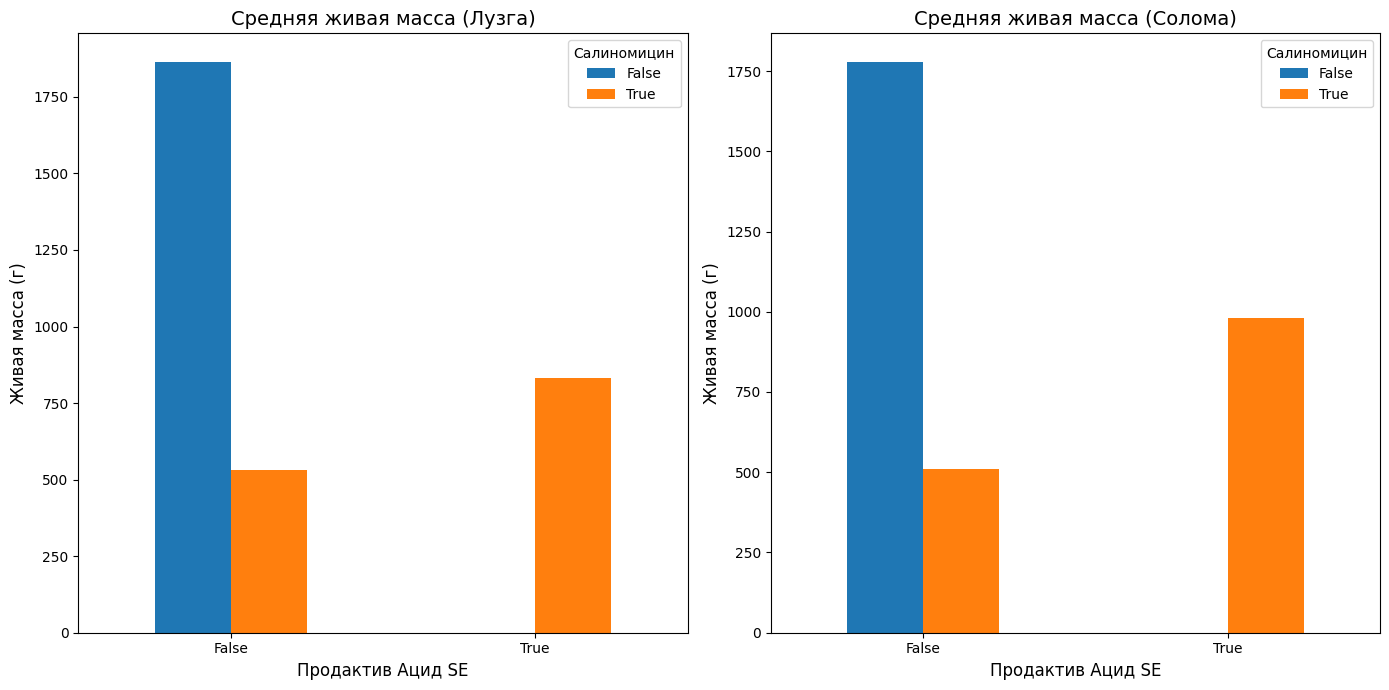

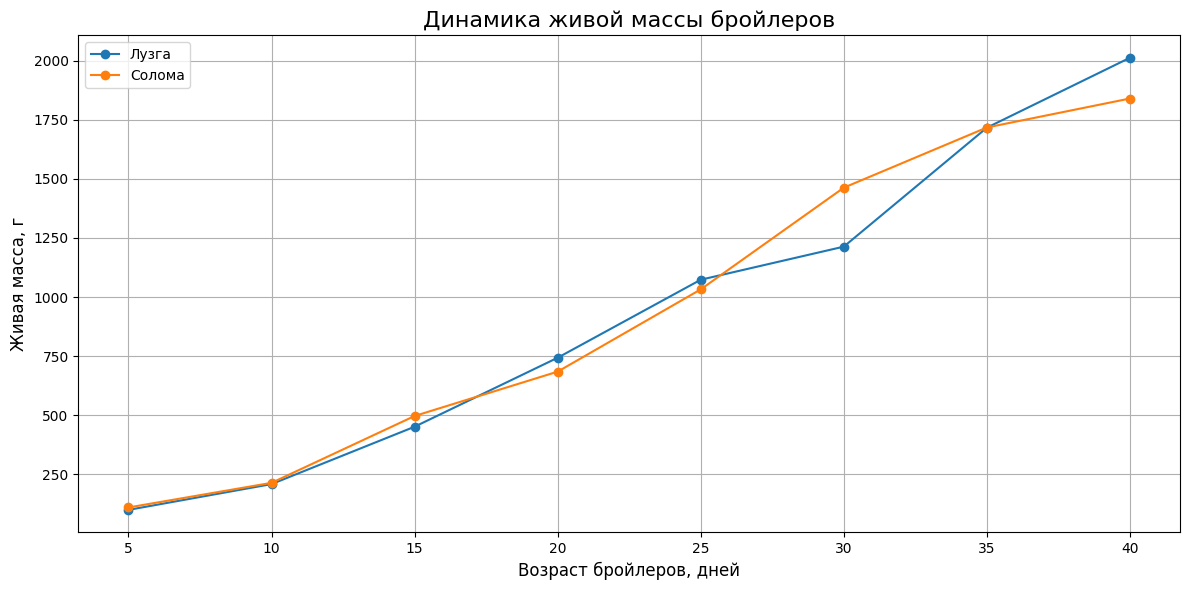

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    '№ П/П': [1, 2, 3, 4, 5, 6, 7, 8],
    'Возраст бройлеров, дней': [5, 10, 15, 20, 25, 30, 35, 40],
    'Продактив Ацид SE': [False, False, True, False, False, True, False, False],
    'Салиномицин': [True, True, True, True, True, True, False, False],
    'Лузга': [99.6, 208.6, 451.4, 743.2, 1073.2, 1213.2, 1716.4, 2012.2],
    'Солома': [109.8, 214, 496.8, 684.4, 1032.4, 1462.6, 1717.2, 1839.8]
}

df = pd.DataFrame(data)

# Группировка данных
df_grouped_luzga = df.groupby(['Продактив Ацид SE', 'Салиномицин'])['Лузга'].mean().unstack()
df_grouped_soloma = df.groupby(['Продактив Ацид SE', 'Салиномицин'])['Солома'].mean().unstack()

# Создание графиков
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 7))

df_grouped_luzga.plot(kind='bar', ax=axes[0], rot=0)
axes[0].set_title('Средняя живая масса (Лузга)', fontsize=14)
axes[0].set_xlabel('Продактив Ацид SE', fontsize=12)
axes[0].set_ylabel('Живая масса (г)', fontsize=12)
axes[0].legend(title='Салиномицин')

df_grouped_soloma.plot(kind='bar', ax=axes[1], rot=0)
axes[1].set_title('Средняя живая масса (Солома)', fontsize=14)
axes[1].set_xlabel('Продактив Ацид SE', fontsize=12)
axes[1].set_ylabel('Живая масса (г)', fontsize=12)
axes[1].legend(title='Салиномицин')

plt.tight_layout()
plt.show()


# Создание линейного графика
plt.figure(figsize=(12, 6)) #Увеличиваем размер графика

#Строим графики живой массы в зависимости от возраста
plt.plot(df['Возраст бройлеров, дней'], df['Лузга'], marker='o', label='Лузга')
plt.plot(df['Возраст бройлеров, дней'], df['Солома'], marker='o', label='Солома')

#Настройка графика
plt.title('Динамика живой массы бройлеров', fontsize=16)
plt.xlabel('Возраст бройлеров, дней', fontsize=12)
plt.ylabel('Живая масса, г', fontsize=12)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

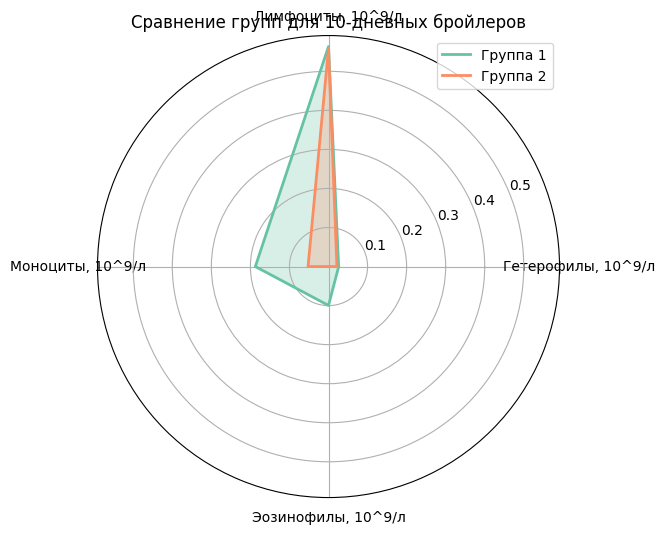

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Предыдущий код для создания DataFrame (как в предыдущем ответе)
data = {
    'Возраст': ['10 дней', '10 дней', '10 дней (норма)',
                '20 дней', '20 дней', '20 дней (норма)',
                '30 дней', '30 дней', '30 дней (норма)',
                '40 дней', '40 дней', '40 дней (норма)'],
    'Группа': [1, 2, np.nan, 1, 2, np.nan, 1, 2, np.nan, 1, 2, np.nan],
    'Гетерофилы, 10^9/л': [1.4572, 1.204, 56, 2.16, 1.79, 56, 0.5694, 1.005, 56, 26.83, 8.5012, 56],
    'Лимфоциты, 10^9/л': [3.944, 3.9118, 7, 11.4, 12.656, 7, 0.9662, 0.82, 7, 2.471, 4.7646, 7],
    'Моноциты, 10^9/л': [1.499, 0.4193, 8, 0.856, 0.462, 8, 0.168, 0.205, 8, 5.648, 0.408, 8],
    'Эозинофилы, 10^9/л': [0.1992, 0.0, 2, 0.39, 0.15, 2, 0.0448, 0.154, 2, 0.0, 0.835, 2],
    'Базофилы, 10^9/л': [0.333, 0.426, 3.5, 0.884, 0.768, 3.5, 0.196, 3.5, 3.5, 0.0, 0.943, 3.5],
    'Эритроциты, 10^12/л': [2.978, 3.104, 30, 2.4, 2.294, 30, 2.332, 2.032, 30, 1.68, 2.188, 30],
    'Лейкоциты, 10^9/л': [6.58, 5.748, 66, 15.5, 15.76, 66, 1.96, 2.096, 66, 35.3, 15.268, 66],
    'Тромбоциты, 10^9/л': [101.6, 88.0, 66, 94.8, 59.0, 66, 214.6, 185.6, 66, 201.0, 219.4, 66]
}

df = pd.DataFrame(data)

# Выбор параметров для диаграммы (пример)
parameters = ['Гетерофилы, 10^9/л', 'Лимфоциты, 10^9/л', 'Моноциты, 10^9/л', 'Эозинофилы, 10^9/л']

# Выбор данных для построения (пример: 10-дневные бройлеры, группы 1 и 2)
data_group1 = df[(df['Возраст'] == '10 дней') & (df['Группа'] == 1)][parameters].values.flatten().tolist()
data_group2 = df[(df['Возраст'] == '10 дней') & (df['Группа'] == 2)][parameters].values.flatten().tolist()
data_norm = df[(df['Возраст'] == '10 дней (норма)')][parameters].values.flatten().tolist()

# Замена строковых значений нормальными значениями
for i in range(len(data_norm)):
    try:
        data_norm[i] = float(data_norm[i])
    except ValueError:
        data_norm[i] = np.nan

# Convert strings to floats and handle NaN values
for i in range(len(parameters)):
    df[parameters[i]] = pd.to_numeric(df[parameters[i]], errors='coerce')

# Function to normalize data to a range of 0-1
def normalize_data(data, norm):
    normalized_data = []
    for i in range(len(data)):
        normalized_data.append(data[i] / norm[i])  # Divide by corresponding normal value
    return normalized_data
# Нормализация к значениям нормы
data_group1_norm = normalize_data(data_group1, data_norm)
data_group2_norm = normalize_data(data_group2, data_norm)

# Подготовка углов для графика
angles = np.linspace(0, 2*np.pi, len(parameters), endpoint=False)
angles = np.concatenate((angles,[angles[0]]))

# Создание графика
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

# Функция для построения радара
def plot_radar(data, color, label):
    data = np.concatenate((data,[data[0]]))
    ax.plot(angles, data, color=color, linewidth=2, label=label)
    ax.fill(angles, data, color=color, alpha=0.25)

# Построение радаров для групп
plot_radar(data_group1_norm, '#66c2a5', 'Группа 1')
plot_radar(data_group2_norm, '#fc8d62', 'Группа 2')
# Настройка графика
ax.set_xticks(angles[:-1])
ax.set_xticklabels(parameters)
ax.set_title('Сравнение групп для 10-дневных бройлеров')
ax.grid(True)
ax.legend()

plt.show()


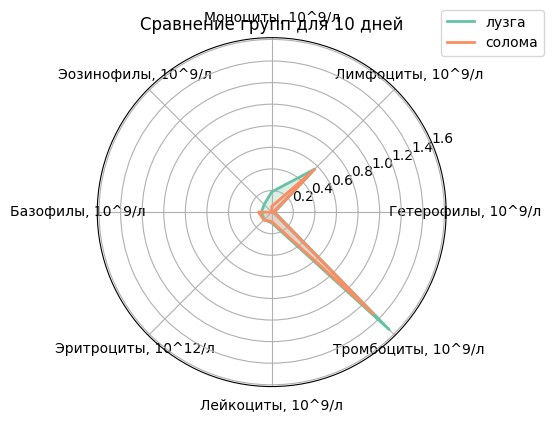

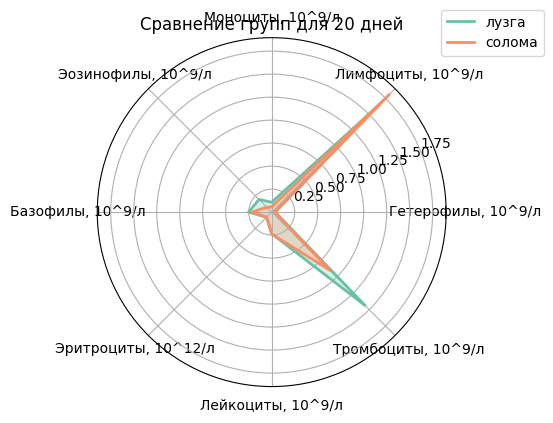

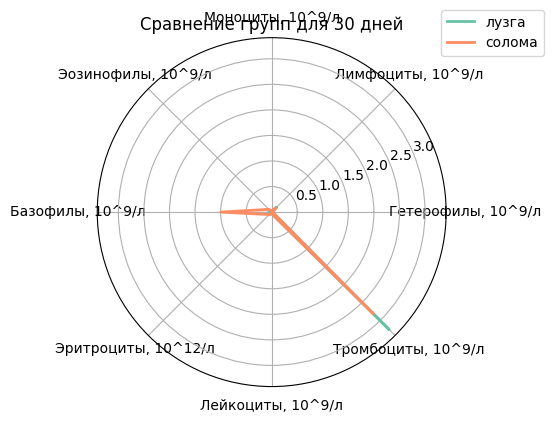

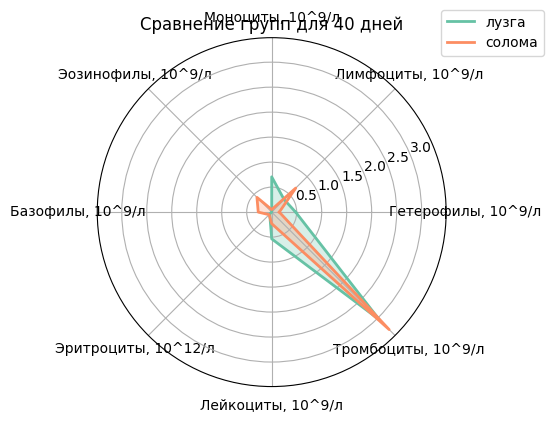

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# (Тот же код для создания DataFrame, что и раньше)
data = {
    'Возраст': ['10 дней', '10 дней', '10 дней (норма)',
                '20 дней', '20 дней', '20 дней (норма)',
                '30 дней', '30 дней', '30 дней (норма)',
                '40 дней', '40 дней', '40 дней (норма)'],
    'Группа': [1, 2, np.nan, 1, 2, np.nan, 1, 2, np.nan, 1, 2, np.nan],
    'Гетерофилы, 10^9/л': [1.4572, 1.204, 56, 2.16, 1.79, 56, 0.5694, 1.005, 56, 26.83, 8.5012, 56],
    'Лимфоциты, 10^9/л': [3.944, 3.9118, 7, 11.4, 12.656, 7, 0.9662, 0.82, 7, 2.471, 4.7646, 7],
    'Моноциты, 10^9/л': [1.499, 0.4193, 8, 0.856, 0.462, 8, 0.168, 0.205, 8, 5.648, 0.408, 8],
    'Эозинофилы, 10^9/л': [0.1992, 0.0, 2, 0.39, 0.15, 2, 0.0448, 0.154, 2, 0.0, 0.835, 2],
    'Базофилы, 10^9/л': [0.333, 0.426, 3.5, 0.884, 0.768, 3.5, 0.196, 3.5, 3.5, 0.0, 0.943, 3.5],
    'Эритроциты, 10^12/л': [2.978, 3.104, 30, 2.4, 2.294, 30, 2.332, 2.032, 30, 1.68, 2.188, 30],
    'Лейкоциты, 10^9/л': [6.58, 5.748, 66, 15.5, 15.76, 66, 1.96, 2.096, 66, 35.3, 15.268, 66],
    'Тромбоциты, 10^9/л': [101.6, 88.0, 66, 94.8, 59.0, 66, 214.6, 185.6, 66, 201.0, 219.4, 66]
}

df = pd.DataFrame(data)
# Преобразуем в численные, некорректные значения заменяем на NaN
for col in df.columns[2:]:  # Начинаем с третьего столбца
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Возрастные группы
возрасты = ['10 дней', '20 дней', '30 дней', '40 дней']

# Параметры для радарной диаграммы
parameters = ['Гетерофилы, 10^9/л', 'Лимфоциты, 10^9/л', 'Моноциты, 10^9/л', 'Эозинофилы, 10^9/л', 'Базофилы, 10^9/л', 'Эритроциты, 10^12/л', 'Лейкоциты, 10^9/л', 'Тромбоциты, 10^9/л']

# Функция нормализации данных
def normalize_data(data, norm):
    return [d / n if n != 0 else 0 for d, n in zip(data, norm)] # Добавлена проверка на ноль

# Цикл по возрастам
for возраст in возрасты:
    # Получаем данные для каждой группы и нормы
    data_group1 = df[(df['Возраст'] == возраст) & (df['Группа'] == 1)][parameters].values.flatten().tolist()
    data_group2 = df[(df['Возраст'] == возраст) & (df['Группа'] == 2)][parameters].values.flatten().tolist()
    data_norm = df[df['Возраст'] == возраст + ' (норма)'][parameters].values.flatten().tolist()

    # Нормализация данных относительно нормы
    data_group1_norm = normalize_data(data_group1, data_norm)
    data_group2_norm = normalize_data(data_group2, data_norm)

    # Углы для графика
    angles = np.linspace(0, 2 * np.pi, len(parameters), endpoint=False)
    angles = np.concatenate((angles, [angles[0]]))

    # Создаем фигуру и axes
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))  # Увеличен размер

    # Функция построения радара
    def plot_radar(data, color, label):
        data = np.concatenate((data, [data[0]]))
        ax.plot(angles, data, color=color, linewidth=2, label=label)
        ax.fill(angles, data, color=color, alpha=0.25)

    # Строим радары
    plot_radar(data_group1_norm, '#66c2a5', 'лузга')
    plot_radar(data_group2_norm, '#fc8d62', 'солома')

    # Настройка графика
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(parameters)
    ax.set_title(f'Сравнение групп для {возраст}')  # Заголовок с возрастом
    ax.grid(True)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))  # Легенда за пределами графика
    plt.tight_layout(rect=[0, 0, 0.8, 1])  # Добавлен tight_layout, уменьшен rect, чтобы вместить легенду

    plt.show()


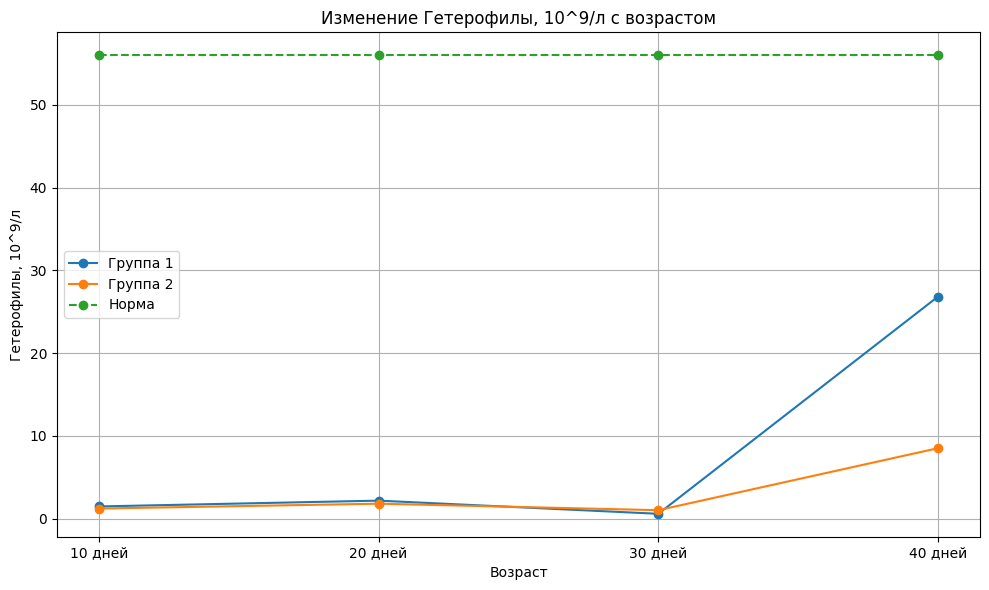

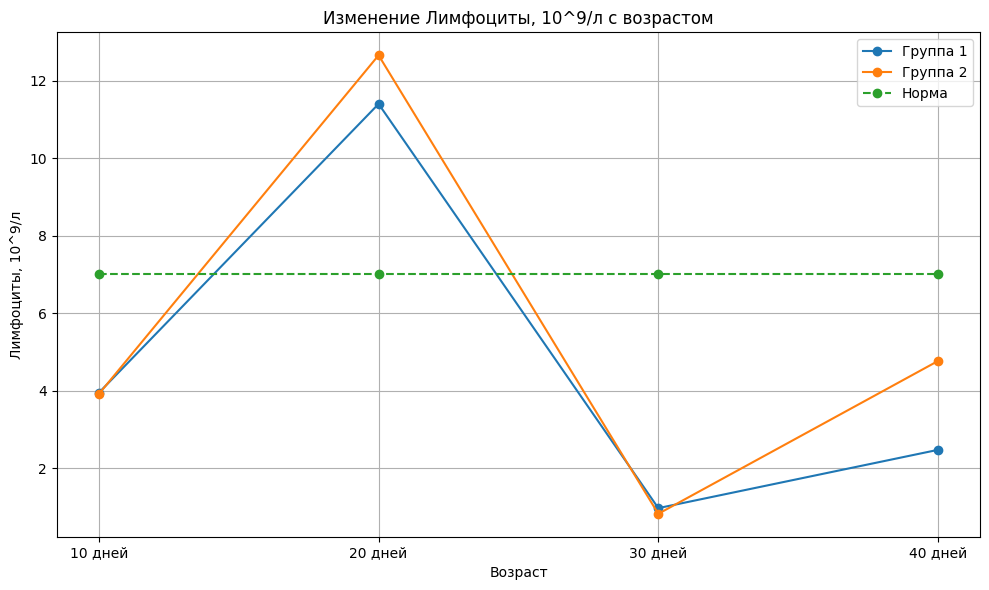

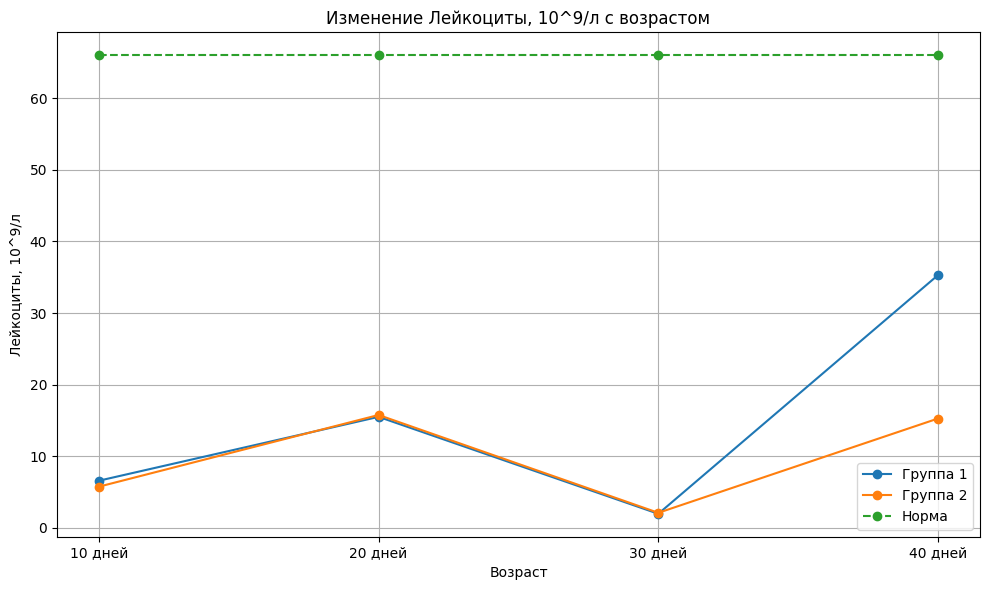

In [26]:
# Преобразуем в численные, некорректные значения заменяем на NaN
for col in df.columns[2:]:  # Начинаем с третьего столбца
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Возрастные группы для оси x
возрасты = ['10 дней', '20 дней', '30 дней', '40 дней']

# Параметры для анализа (выберите интересующие вас)
parameters = ['Гетерофилы, 10^9/л', 'Лимфоциты, 10^9/л', 'Лейкоциты, 10^9/л'] # Пример

# Создание линейных графиков
for parameter in parameters:
    plt.figure(figsize=(10, 6))  # Размер графика
    # Фильтруем и строим для каждой группы
    group1_values = [df[(df['Возраст'] == age) & (df['Группа'] == 1)][parameter].values[0] for age in возрасты]
    group2_values = [df[(df['Возраст'] == age) & (df['Группа'] == 2)][parameter].values[0] for age in возрасты]
    norm_values = [df[(df['Возраст'] == age + ' (норма)')][parameter].values[0] for age in возрасты]

    plt.plot(возрасты, group1_values, marker='o', label='Группа 1')
    plt.plot(возрасты, group2_values, marker='o', label='Группа 2')
    plt.plot(возрасты, norm_values, marker='o', linestyle='--', label='Норма')

    plt.xlabel('Возраст')
    plt.ylabel(parameter)  # Название параметра на оси y
    plt.title(f'Изменение {parameter} с возрастом')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

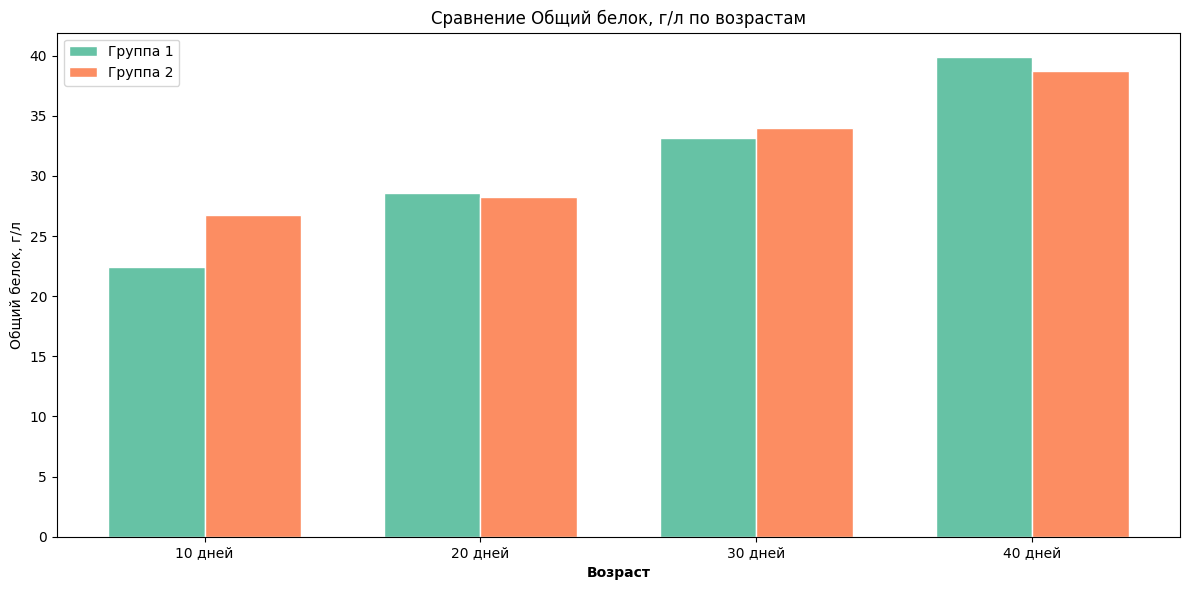

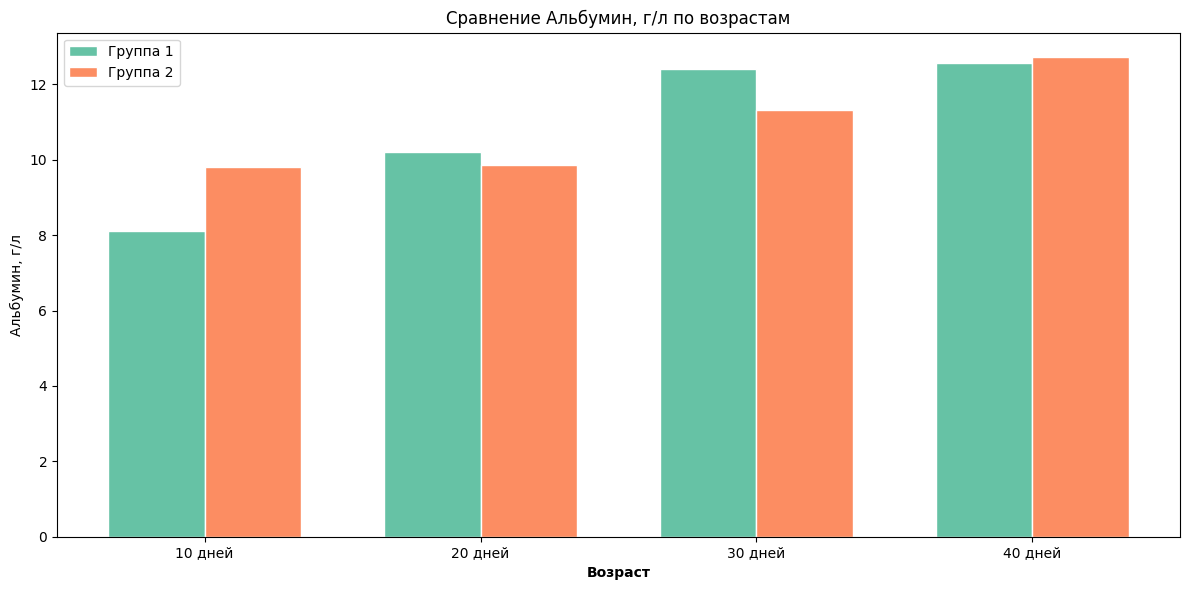

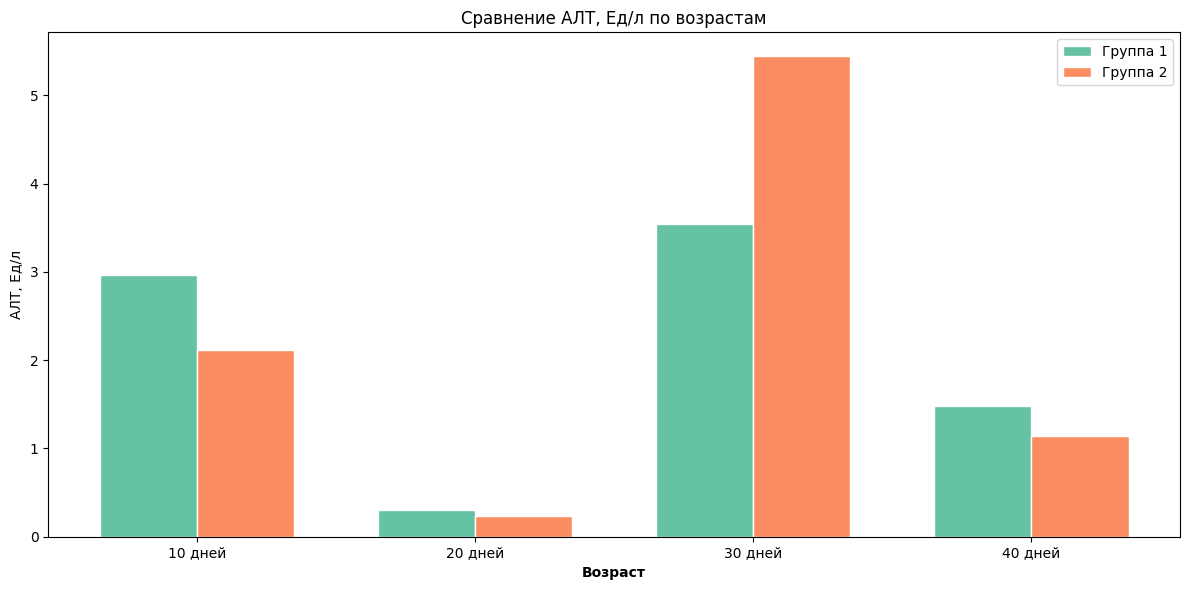

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# DataFrame (как в предыдущем примере)
data = {
    'Возраст': ['10 дней', '10 дней', '20 дней', '20 дней', '30 дней', '30 дней', '40 дней', '40 дней'],
    'Группа': [1, 2, 1, 2, 1, 2, 1, 2],
    'Общий белок, г/л': [22.4, 26.74, 28.54, 28.22, 33.12, 34.02, 39.92, 38.68],
    'Альбумин, г/л': [8.12, 9.8, 10.2, 9.86, 12.42, 11.32, 12.56, 12.74],
    'Мочевина, ммоль/л': [0.636, 0.554, 0.44, 0.368, 0.838, 0.962, 0.352, 0.436],
    'Креатинин, ммоль/л': [13.34, 13.2, 11.02, 12.2, 17.96, 7.4, 31.38, 23.1],
    'Глюкоза, ммоль/л': [15.36, 14.22, 15.14, 14.56, 14.69, 14.71, 12.55, 1.16],
    'Общий билирубин, ммоль/л': [0.3, 0.76, 0.4, 0.26, 1.54, 0.0, 0.2, 0.32],
    'АСТ, Ед/л': [236.5, 256.9, 254.2, 285.3, 310.6, 359.9, 322.5, 322.8],
    'АЛТ, Ед/л': [2.96, 2.12, 0.3, 0.24, 3.54, 5.44, 1.48, 1.14],
    'ЩФ,ЕД/л': [705.52, 1520.26, 3074.78, 4327.66, 4579.48, 4154.58, 3009.56, 2507.38]
}

df = pd.DataFrame(data)

# Параметры для анализа
parameters = ['Общий белок, г/л', 'Альбумин, г/л', 'АЛТ, Ед/л'] # пример

# Ширина столбцов
bar_width = 0.35

# Создаем столбчатые диаграммы для каждого параметра
for parameter in parameters:
    plt.figure(figsize=(12, 6))
    # Позиции столбцов
    r1 = np.arange(len(df['Возраст'].unique())) #  [0 1 2 3]
    r2 = [x + bar_width for x in r1] # [0.35 1.35 2.35 3.35]

    # Данные для группы 1 и 2
    group1_values = df[df['Группа'] == 1][parameter].values
    group2_values = df[df['Группа'] == 2][parameter].values

    # Создаем столбцы
    plt.bar(r1, group1_values, color='#66c2a5', width=bar_width, edgecolor='white', label='Группа 1') #зеленый
    plt.bar(r2, group2_values, color='#fc8d62', width=bar_width, edgecolor='white', label='Группа 2') #оранжевый
    # Добавляем названия на оси x
    plt.xlabel('Возраст', fontweight='bold')
    plt.xticks([r + bar_width/2 for r in range(len(df['Возраст'].unique()))], df['Возраст'].unique())

    plt.ylabel(parameter)
    plt.title(f'Сравнение {parameter} по возрастам')

    plt.legend()
    plt.tight_layout()
    plt.show()
